# Bruising Prediction CNN Test Result Average Analysis

Adapted from `/home/emahan/sysops/HIPPA/hanif/bruising_detection/eda/bruising_prediction_test_results_analysis.ipynb` for averaged bruising detection project outputs.

This notebook analyzes the CNN and PCA-SVM test results from `reports`, `reports_st1`, and `reports_st2`, computes the same overall and grouped metrics for each run, averages those metrics across runs, plots averaged confusion matrices, compares warm/cold conditions, compares impact groups, and lists predictions that were missed in at least one run for inspection.


In [91]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

PROJECT_ROOT = Path('/home/emahan/sysops/HIPPA/hanif/bruising_detection')
REPORT_RUNS = {
    'reports': PROJECT_ROOT / 'reports',
    'reports_st1': PROJECT_ROOT / 'reports_st1',
    'reports_st2': PROJECT_ROOT / 'reports_st2',
}
OUTPUT_DIR = PROJECT_ROOT / 'reports_average'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
REPO_FIGURE_DIR = PROJECT_ROOT / 'figures'
LABELS = [0, 1]
LABEL_NAMES = ['sound', 'bruised']

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPO_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str):
    fig.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches='tight')
    fig.savefig(REPO_FIGURE_DIR / filename, dpi=200, bbox_inches='tight')


def load_predictions(filename):
    frames = []
    for run, report_dir in REPORT_RUNS.items():
        path = report_dir / 'tables' / filename
        run_df = pd.read_csv(path)
        run_df['run'] = run
        run_df['source_csv'] = str(path)
        run_df['sample_id'] = run_df['file'].astype(str) + ' | ' + run_df['timepoint'].astype(str) + ' | ' + run_df['dataset'].astype(str)
        run_df['microtec_id'] = run_df['file'].str.extract(r'MICROTEC_(\d+)')[0]
        run_df['prefix2'] = run_df['microtec_id'].str[:2]
        run_df['prefix3'] = run_df['microtec_id'].str[:3]
        run_df['correct'] = run_df['y_true'].eq(run_df['y_pred'])
        frames.append(run_df)
    return pd.concat(frames, ignore_index=True)


df = load_predictions('cnn_test_predictions.csv')

run_summary = df.groupby('run').agg(
    rows=('sample_id', 'size'),
    files=('file', 'nunique'),
    timepoints=('timepoint', lambda s: ', '.join(sorted(s.astype(str).unique()))),
).reset_index()

display(df.head())
display(run_summary)
print('Runs:', ', '.join(REPORT_RUNS))
print('Total rows across runs:', len(df))


,path,file,group,timepoint,dataset,y,label,box_shape,crop_shape,bands,...,y_pred,y_true_label,y_pred_label,run,source_csv,sample_id,microtec_id,prefix2,prefix3,correct
0,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29405_processed_boxes.h5,SWIR_t0,t0,bruised1,0,sound,"(160, 160)","(160, 160)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_29405_processed_boxes.h5 | t0 | bruised1,29405,29,294,True
1,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29405_processed_boxes.h5,SWIR_t0,t0,bruised2,0,sound,"(160, 160)","(160, 160)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_29405_processed_boxes.h5 | t0 | bruised2,29405,29,294,True
2,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29405_processed_boxes.h5,SWIR_t0,t0,bruised3,0,sound,"(160, 160)","(160, 160)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_29405_processed_boxes.h5 | t0 | bruised3,29405,29,294,True
3,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29405_processed_boxes.h5,SWIR_t0,t0,bruised4,0,sound,"(160, 160)","(160, 160)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_29405_processed_boxes.h5 | t0 | bruised4,29405,29,294,True
4,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29405_processed_boxes.h5,SWIR_t0,t0,sound1,0,sound,"(160, 160)","(160, 160)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_29405_processed_boxes.h5 | t0 | sound1,29405,29,294,True


,run,rows,files,timepoints
0,reports,384,12,"t0, t1, t2, t3"
1,reports_st1,384,12,"t0, t1, t2, t3"
2,reports_st2,384,12,"t0, t1, t2, t3"


Runs: reports, reports_st1, reports_st2
Total rows across runs: 1152


## Train/Validation/Test Sample Counts

This block uses the saved project split sample CSVs in `data/splits`, so it reports the exact split files used by the current project results.


In [92]:
SPLIT_SAMPLE_CSVS = {
    'train': PROJECT_ROOT / 'data' / 'splits' / 'train_samples.csv',
    'val': PROJECT_ROOT / 'data' / 'splits' / 'val_samples.csv',
    'test': PROJECT_ROOT / 'data' / 'splits' / 'test_samples.csv',
}

split_rows = []
for split, path in SPLIT_SAMPLE_CSVS.items():
    split_df = pd.read_csv(path)
    split_rows.append({
        'split': split,
        'n_files': split_df['file'].nunique(),
        'n_samples': len(split_df),
        'n_sound': int((split_df['y'] == 0).sum()),
        'n_bruised': int((split_df['y'] == 1).sum()),
    })

split_summary = pd.DataFrame(split_rows)
total_files = int(split_summary['n_files'].sum())
total_samples = int(split_summary['n_samples'].sum())
total_sound = int(split_summary['n_sound'].sum())
total_bruised = int(split_summary['n_bruised'].sum())
split_summary['file_ratio'] = (split_summary['n_files'] / total_files).round(4)
split_summary['sample_ratio'] = (split_summary['n_samples'] / total_samples).round(4)
split_summary = pd.concat([
    split_summary,
    pd.DataFrame([{
        'split': 'total',
        'n_files': total_files,
        'n_samples': total_samples,
        'n_sound': total_sound,
        'n_bruised': total_bruised,
        'file_ratio': 1.0,
        'sample_ratio': 1.0,
    }]),
], ignore_index=True)

display(split_summary)
split_summary.to_csv(TABLE_DIR / 'bruising_prediction_split_sample_summary.csv', index=False)


,split,n_files,n_samples,n_sound,n_bruised,file_ratio,sample_ratio
0,train,94,3008,1880,1128,0.7966,0.7966
1,val,12,384,240,144,0.1017,0.1017
2,test,12,384,240,144,0.1017,0.1017
3,total,118,3776,2360,1416,1.0000,1.0000


In [93]:
METRIC_COLUMNS = [
    'n', 'correct', 'incorrect', 'true_negative', 'false_positive', 'false_negative', 'true_positive',
    'n_true_positive_samples', 'n_predicted_positive_samples', 'accuracy', 'precision', 'recall', 'f1',
]
COUNT_COLUMNS = [
    'n', 'correct', 'incorrect', 'true_negative', 'false_positive', 'false_negative', 'true_positive',
    'n_true_positive_samples', 'n_predicted_positive_samples',
]
RATE_COLUMNS = ['accuracy', 'precision', 'recall', 'f1']


def metric_row(data, name=None):
    y_true = data['y_true'].to_numpy()
    y_pred = data['y_pred'].to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=LABELS).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    row = {
        'n': int(len(data)),
        'correct': int((y_true == y_pred).sum()),
        'incorrect': int((y_true != y_pred).sum()),
        'true_negative': int(tn),
        'false_positive': int(fp),
        'false_negative': int(fn),
        'true_positive': int(tp),
        'n_true_positive_samples': int((y_true == 1).sum()),
        'n_predicted_positive_samples': int((y_pred == 1).sum()),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }
    if name is not None:
        row = {'group': name, **row}
    return row


def metrics_by(data, group_col):
    return pd.DataFrame([metric_row(g, name) for name, g in data.groupby(group_col, sort=True)]).reset_index(drop=True)


def run_metrics(data, metric_func):
    rows = []
    for run, run_df in data.groupby('run', sort=True):
        metrics = metric_func(run_df).copy()
        metrics.insert(0, 'run', run)
        rows.append(metrics)
    return pd.concat(rows, ignore_index=True)


def average_metrics(run_level, group_cols=('group',)):
    group_cols = list(group_cols)
    averaged = run_level.groupby(group_cols, dropna=False)[METRIC_COLUMNS].agg(['mean', 'std', 'min', 'max'])
    averaged.columns = [f'{metric}_{stat}' for metric, stat in averaged.columns]
    averaged = averaged.reset_index()
    averaged.insert(len(group_cols), 'n_runs', run_level.groupby(group_cols, dropna=False)['run'].nunique().to_numpy())
    for col in averaged.columns:
        if col.endswith(('_mean', '_std', '_min', '_max')):
            averaged[col] = averaged[col].round(4)
    return averaged



def display_accuracy(label, table):
    accuracy_cols = [
        col for col in ['run', 'group', 'n_runs', 'accuracy', 'accuracy_mean', 'accuracy_min', 'accuracy_max']
        if col in table.columns
    ]
    print(label)
    display(table[accuracy_cols].round(4))


def order_groups(table, order, group_col='group'):
    ordered = table.copy()
    ordered['_group_order'] = pd.Categorical(ordered[group_col], categories=order, ordered=True)
    ordered = ordered.sort_values('_group_order').drop(columns='_group_order').reset_index(drop=True)
    return ordered



def correctness_table(data, group_col, order):
    rows = []
    for group in order:
        g = data[data[group_col] == group]
        rows.append({
            'group': group,
            'correct': int(g['correct'].sum()),
            'incorrect': int((~g['correct']).sum()),
            'n': int(len(g)),
            'accuracy': round(float(g['correct'].mean()), 4) if len(g) else np.nan,
        })
    return pd.DataFrame(rows)


def test_correctness_groups(data, group_col, order, comparison_name):
    counts = correctness_table(data, group_col, order)
    contingency = counts[['correct', 'incorrect']].to_numpy()
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency, correction=False)
    result = {
        'comparison': comparison_name,
        'test': 'chi-square test of independence',
        'groups': ' vs '.join(order),
        'chi2': chi2,
        'dof': int(dof),
        'p_value': p_value,
    }
    if len(order) == 2:
        oddsratio, fisher_p = stats.fisher_exact(contingency)
        result.update({'fisher_exact_oddsratio': oddsratio, 'fisher_exact_p_value': fisher_p})
    return counts, pd.DataFrame([result])


def pairwise_correctness_tests(data, group_col, order, comparison_name):
    rows = []
    for i, group_a in enumerate(order):
        for group_b in order[i + 1:]:
            subset = data[data[group_col].isin([group_a, group_b])]
            counts, test = test_correctness_groups(subset, group_col, [group_a, group_b], comparison_name)
            row = test.iloc[0].to_dict()
            row['group_a'] = group_a
            row['group_b'] = group_b
            row['accuracy_a'] = counts.loc[counts['group'] == group_a, 'accuracy'].iloc[0]
            row['accuracy_b'] = counts.loc[counts['group'] == group_b, 'accuracy'].iloc[0]
            rows.append(row)
    out = pd.DataFrame(rows)
    if len(out):
        out['holm_rank'] = out['p_value'].rank(method='first').astype(int)
        m = len(out)
        out = out.sort_values('p_value').reset_index(drop=True)
        out['holm_adjusted_p_value'] = [(m - idx) * pval for idx, pval in enumerate(out['p_value'])]
        out['holm_adjusted_p_value'] = out['holm_adjusted_p_value'].clip(upper=1.0)
    return out


def run_level_correctness_tests(data, group_col, order, comparison_name):
    rows = []
    for run, run_df in data.groupby('run', sort=True):
        _, test = test_correctness_groups(run_df, group_col, order, comparison_name)
        row = test.iloc[0].to_dict()
        row['run'] = run
        rows.append(row)
    return pd.DataFrame(rows)



def mcnemar_exact_p_value(b, c):
    discordant = int(b + c)
    if discordant == 0:
        return 1.0
    if hasattr(stats, 'binomtest'):
        return float(stats.binomtest(min(b, c), discordant, 0.5).pvalue)
    return float(stats.binom_test(min(b, c), discordant, 0.5))


def compare_paired_model_correctness(cnn_data, svm_data, comparison_name):
    cnn_cols = cnn_data[['run', 'sample_id', 'correct']].rename(columns={'correct': 'cnn_correct'})
    svm_cols = svm_data[['run', 'sample_id', 'correct']].rename(columns={'correct': 'svm_correct'})
    paired = cnn_cols.merge(svm_cols, on=['run', 'sample_id'], how='inner')
    if len(paired) != len(cnn_cols) or len(paired) != len(svm_cols):
        raise ValueError(f'Matched {len(paired)} rows, expected {len(cnn_cols)} CNN rows and {len(svm_cols)} PCA-SVM rows')

    both_correct = int((paired['cnn_correct'] & paired['svm_correct']).sum())
    cnn_only_correct = int((paired['cnn_correct'] & ~paired['svm_correct']).sum())
    svm_only_correct = int((~paired['cnn_correct'] & paired['svm_correct']).sum())
    both_incorrect = int((~paired['cnn_correct'] & ~paired['svm_correct']).sum())
    discordant = cnn_only_correct + svm_only_correct
    if discordant:
        chi2_continuity = (abs(cnn_only_correct - svm_only_correct) - 1) ** 2 / discordant
        chi2_p_value = float(stats.chi2.sf(chi2_continuity, 1))
    else:
        chi2_continuity = 0.0
        chi2_p_value = 1.0

    counts = pd.DataFrame([{
        'comparison': comparison_name,
        'n_matched': int(len(paired)),
        'both_correct': both_correct,
        'cnn_only_correct': cnn_only_correct,
        'svm_only_correct': svm_only_correct,
        'both_incorrect': both_incorrect,
        'cnn_accuracy': round(float(paired['cnn_correct'].mean()), 4),
        'svm_accuracy': round(float(paired['svm_correct'].mean()), 4),
    }])
    test = pd.DataFrame([{
        'comparison': comparison_name,
        'test': 'McNemar exact binomial test on paired correctness',
        'n_discordant': discordant,
        'cnn_only_correct': cnn_only_correct,
        'svm_only_correct': svm_only_correct,
        'exact_p_value': mcnemar_exact_p_value(cnn_only_correct, svm_only_correct),
        'mcnemar_chi2_continuity': chi2_continuity,
        'mcnemar_chi2_p_value': chi2_p_value,
    }])
    return counts, test


def plot_confusion(cm, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(range(len(LABEL_NAMES)), LABEL_NAMES)
    ax.set_yticks(range(len(LABEL_NAMES)), LABEL_NAMES)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    threshold = cm.max() / 2 if cm.size and cm.max() else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            label = f'{value:.1f}' if isinstance(value, (float, np.floating)) and not float(value).is_integer() else f'{int(round(value))}'
            ax.text(j, i, label, ha='center', va='center', color='white' if value > threshold else 'black')
    return im


## Overall Confusion Matrix


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,overall,384,363,21,238,2,19,125,144,127,0.9453,0.9843,0.8681,0.9225
1,reports_st1,overall,384,352,32,227,13,19,125,144,138,0.9167,0.9058,0.8681,0.8865
2,reports_st2,overall,384,368,16,231,9,7,137,144,146,0.9583,0.9384,0.9514,0.9448


Accuracy by run


,run,group,accuracy
0,reports,overall,0.9453
1,reports_st1,overall,0.9167
2,reports_st2,overall,0.9583


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,overall,3,384.0,0.0,384,384,361.0,8.1854,352,368,...,0.9058,0.9843,0.8958,0.0481,0.8681,0.9514,0.918,0.0294,0.8865,0.9448


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,overall,3,0.9401,0.9167,0.9583


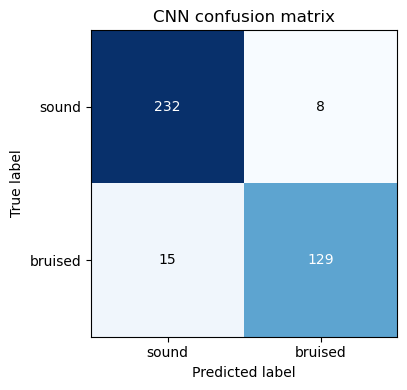

In [94]:
overall_by_run = run_metrics(df, lambda run_df: pd.DataFrame([metric_row(run_df, 'overall')]))
overall_average = average_metrics(overall_by_run)

display(overall_by_run.round(4))
display_accuracy('Accuracy by run', overall_by_run)
display(overall_average)
display_accuracy('Average accuracy', overall_average)
overall_by_run.to_csv(TABLE_DIR / 'bruising_prediction_test_overall_metrics_by_run.csv', index=False)
overall_average.to_csv(TABLE_DIR / 'bruising_prediction_test_overall_metrics_average.csv', index=False)

mean_cm = overall_by_run[['true_negative', 'false_positive', 'false_negative', 'true_positive']].mean().to_numpy().reshape(2, 2)
fig, ax = plt.subplots(figsize=(4.5, 4))
plot_confusion(mean_cm, 'CNN confusion matrix', ax=ax)
plt.tight_layout()
save_figure(fig, 'bruising_prediction_overall_confusion_average.png')
plt.show()


## Accuracy, Precision, Recall by Timepoint


In [95]:
timepoint_metrics_by_run = run_metrics(df, lambda run_df: metrics_by(run_df, 'timepoint'))
timepoint_metrics_average = average_metrics(timepoint_metrics_by_run)

display(timepoint_metrics_by_run.round(4))
display_accuracy('Accuracy by run', timepoint_metrics_by_run)
display(timepoint_metrics_average)
display_accuracy('Average accuracy', timepoint_metrics_average)
timepoint_metrics_by_run.to_csv(TABLE_DIR / 'bruising_prediction_test_metrics_by_timepoint_by_run.csv', index=False)
timepoint_metrics_average.to_csv(TABLE_DIR / 'bruising_prediction_test_metrics_by_timepoint_average.csv', index=False)


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,t0,96,94,2,94,2,0,0,0,2,0.9792,0.0000,0.0000,0.0000
1,reports,t1,96,88,8,48,0,8,40,48,40,0.9167,1.0000,0.8333,0.9091
2,reports,t2,96,86,10,48,0,10,38,48,38,0.8958,1.0000,0.7917,0.8837
3,reports,t3,96,95,1,48,0,1,47,48,47,0.9896,1.0000,0.9792,0.9895
4,reports_st1,t0,96,86,10,86,10,0,0,0,10,0.8958,0.0000,0.0000,0.0000
5,reports_st1,t1,96,85,11,47,1,10,38,48,39,0.8854,0.9744,0.7917,0.8736
6,reports_st1,t2,96,88,8,47,1,7,41,48,42,0.9167,0.9762,0.8542,0.9111
7,reports_st1,t3,96,93,3,47,1,2,46,48,47,0.9688,0.9787,0.9583,0.9684
8,reports_st2,t0,96,94,2,94,2,0,0,0,2,0.9792,0.0000,0.0000,0.0000
9,reports_st2,t1,96,89,7,46,2,5,43,48,45,0.9271,0.9556,0.8958,0.9247


Accuracy by run


,run,group,accuracy
0,reports,t0,0.9792
1,reports,t1,0.9167
2,reports,t2,0.8958
3,reports,t3,0.9896
4,reports_st1,t0,0.8958
5,reports_st1,t1,0.8854
6,reports_st1,t2,0.9167
7,reports_st1,t3,0.9688
8,reports_st2,t0,0.9792
9,reports_st2,t1,0.9271


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,t0,3,96.0,0.0,96,96,91.3333,4.6188,86,94,...,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,t1,3,96.0,0.0,96,96,87.3333,2.0817,85,89,...,0.9556,1.0,0.8403,0.0524,0.7917,0.8958,0.9025,0.0262,0.8736,0.9247
2,t2,3,96.0,0.0,96,96,88.6667,3.0551,86,92,...,0.9583,1.0,0.8681,0.0842,0.7917,0.9583,0.9177,0.0377,0.8837,0.9583
3,t3,3,96.0,0.0,96,96,93.6667,1.1547,93,95,...,0.9412,1.0,0.9792,0.0208,0.9583,1.0000,0.9759,0.0118,0.9684,0.9895


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,t0,3,0.9514,0.8958,0.9792
1,t1,3,0.9097,0.8854,0.9271
2,t2,3,0.9236,0.8958,0.9583
3,t3,3,0.9757,0.9688,0.9896


## Confusion Matrix per Timepoint


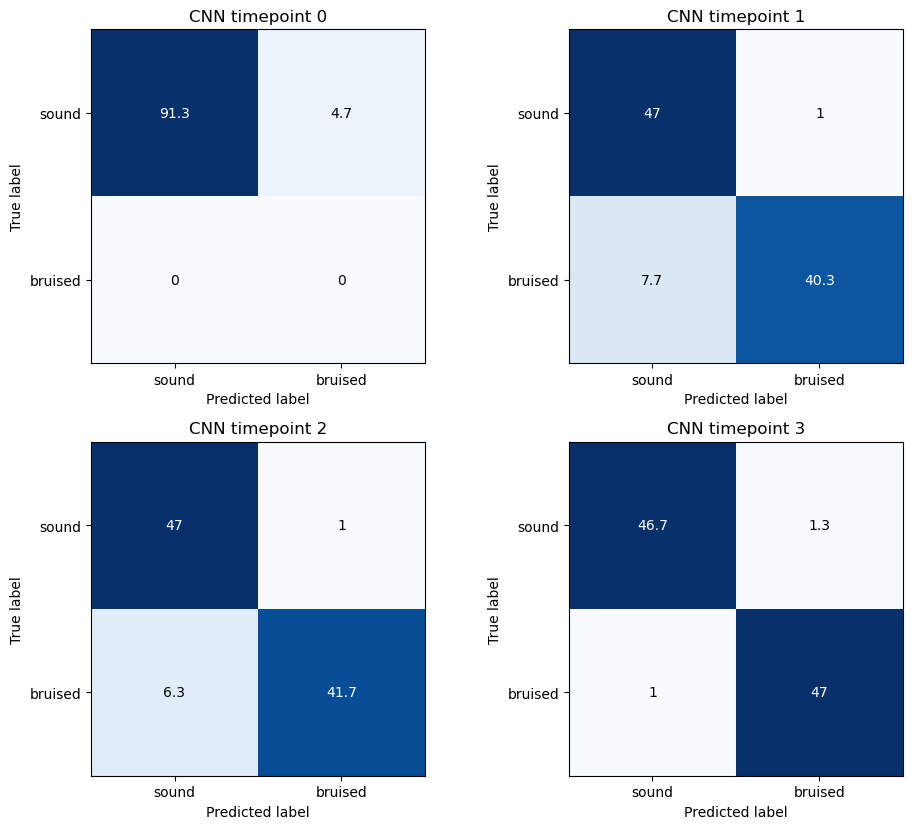

In [96]:
timepoints = sorted(df['timepoint'].astype(str).unique())
ncols = 2
nrows = int(np.ceil(len(timepoints) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, tp in zip(axes, timepoints):
    g = timepoint_metrics_by_run[timepoint_metrics_by_run['group'].astype(str) == tp]
    cm = g[['true_negative', 'false_positive', 'false_negative', 'true_positive']].mean().to_numpy().reshape(2, 2)
    plot_confusion(cm, f"CNN timepoint {str(tp).lstrip('t')}", ax=ax)

for ax in axes[len(timepoints):]:
    ax.axis('off')

plt.tight_layout()
save_figure(fig, 'bruising_prediction_timepoint_confusion_average.png')
plt.show()


## Comparison: Warm vs Cold Condition

Warm/cold groups are derived from the MICROTEC id prefix in the filename, matching the source notebook logic.


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,warm,192,182,10,119,1,9,63,72,64,0.9479,0.9844,0.8750,0.9265
1,reports,cold,192,181,11,119,1,10,62,72,63,0.9427,0.9841,0.8611,0.9185
2,reports_st1,warm,192,170,22,109,11,11,61,72,72,0.8854,0.8472,0.8472,0.8472
3,reports_st1,cold,192,182,10,118,2,8,64,72,66,0.9479,0.9697,0.8889,0.9275
4,reports_st2,warm,192,183,9,114,6,3,69,72,75,0.9531,0.9200,0.9583,0.9388
5,reports_st2,cold,192,185,7,117,3,4,68,72,71,0.9635,0.9577,0.9444,0.9510


Accuracy by run


,run,group,accuracy
0,reports,warm,0.9479
1,reports,cold,0.9427
2,reports_st1,warm,0.8854
3,reports_st1,cold,0.9479
4,reports_st2,warm,0.9531
5,reports_st2,cold,0.9635


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,cold,3,192.0,0.0,192,192,182.6667,2.0817,181,185,...,0.9577,0.9841,0.8981,0.0424,0.8611,0.9444,0.9324,0.0168,0.9185,0.9510
1,warm,3,192.0,0.0,192,192,178.3333,7.2342,170,183,...,0.8472,0.9844,0.8935,0.0578,0.8472,0.9583,0.9042,0.0497,0.8472,0.9388


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,cold,3,0.9514,0.9427,0.9635
1,warm,3,0.9288,0.8854,0.9531


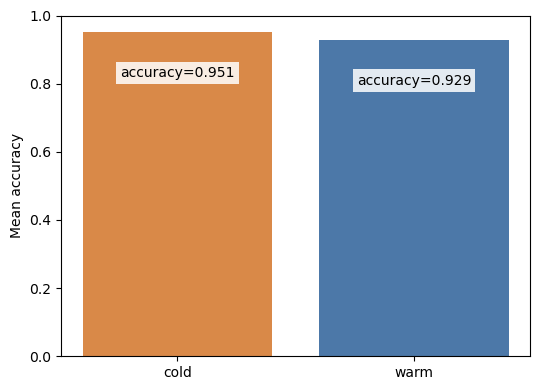

In [97]:
def warm_cold_metrics(run_df):
    compare_warm_cold = run_df[run_df['prefix2'].isin(['28', '29'])].copy()
    compare_warm_cold['comparison_group'] = compare_warm_cold['prefix2'].map({'28': 'warm', '29': 'cold'})
    metrics = metrics_by(compare_warm_cold, 'comparison_group')
    return metrics.set_index('group').loc[['warm', 'cold']].reset_index()

metrics_warm_cold_by_run = run_metrics(df, warm_cold_metrics)
metrics_warm_cold_average = average_metrics(metrics_warm_cold_by_run)

display(metrics_warm_cold_by_run.round(4))
display_accuracy('Accuracy by run', metrics_warm_cold_by_run)
display(metrics_warm_cold_average)
display_accuracy('Average accuracy', metrics_warm_cold_average)
metrics_warm_cold_by_run.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_warm_cold_by_run.csv', index=False)
metrics_warm_cold_average.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_warm_cold_average.csv', index=False)

fig, ax = plt.subplots(figsize=(5.5, 4.0))
bars = ax.bar(metrics_warm_cold_average['group'], metrics_warm_cold_average['accuracy_mean'], color=['#d98948', '#4c78a8'])
ax.set_ylim(0, 1)
ax.set_ylabel('Mean accuracy')
ax.set_title('')
for bar, (_, row) in zip(bars, metrics_warm_cold_average.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, max(row['accuracy_mean'] - 0.12, 0.08), f"accuracy={row['accuracy_mean']:.3f}", ha='center', va='center', color='black', fontsize=10, bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3})
plt.tight_layout()
save_figure(fig, 'bruising_prediction_warm_cold_accuracy_average.png')
plt.show()


## Statistical Test: Warm vs Cold Condition


In [98]:
warm_cold_test_df = df[df['prefix2'].isin(['28', '29'])].copy()
warm_cold_test_df['comparison_group'] = warm_cold_test_df['prefix2'].map({'28': 'warm', '29': 'cold'})

warm_cold_counts, warm_cold_pooled_test = test_correctness_groups(
    warm_cold_test_df,
    'comparison_group',
    ['warm', 'cold'],
    'CNN warm vs cold correctness',
)
warm_cold_run_tests = run_level_correctness_tests(
    warm_cold_test_df,
    'comparison_group',
    ['warm', 'cold'],
    'CNN warm vs cold correctness',
)

display(warm_cold_counts)
display(warm_cold_pooled_test.round(6))
display(warm_cold_run_tests[['run', 'test', 'groups', 'chi2', 'dof', 'p_value', 'fisher_exact_p_value']].round(6))
warm_cold_counts.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_warm_cold_stat_counts.csv', index=False)
warm_cold_pooled_test.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_warm_cold_stat_test_pooled.csv', index=False)
warm_cold_run_tests.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_warm_cold_stat_tests_by_run.csv', index=False)


,group,correct,incorrect,n,accuracy
0,warm,535,41,576,0.9288
1,cold,548,28,576,0.9514


,comparison,test,groups,chi2,dof,p_value,fisher_exact_oddsratio,fisher_exact_p_value
0,CNN warm vs cold correctness,chi-square test of independence,warm vs cold,2.605323,1,0.106505,0.666726,0.135733


,run,test,groups,chi2,dof,p_value,fisher_exact_p_value
0,reports,chi-square test of independence,warm vs cold,0.050374,1,0.822414,1.000000
1,reports_st1,chi-square test of independence,warm vs cold,4.909091,1,0.026716,0.040820
2,reports_st2,chi-square test of independence,warm vs cold,0.260870,1,0.609523,0.799401


## Comparison: Low, Medium, and High Impact

Impact groups are derived from the first three digits of the MICROTEC id, matching the project EDA grouping.


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,low impact,128,114,14,80,0,14,34,48,34,0.8906,1.0000,0.7083,0.8293
1,reports,medium impact,128,122,6,79,1,5,43,48,44,0.9531,0.9773,0.8958,0.9348
2,reports,high impact,128,127,1,79,1,0,48,48,49,0.9922,0.9796,1.0000,0.9897
3,reports_st1,low impact,128,113,15,80,0,15,33,48,33,0.8828,1.0000,0.6875,0.8148
4,reports_st1,medium impact,128,122,6,78,2,4,44,48,46,0.9531,0.9565,0.9167,0.9362
5,reports_st1,high impact,128,117,11,69,11,0,48,48,59,0.9141,0.8136,1.0000,0.8972
6,reports_st2,low impact,128,123,5,80,0,5,43,48,43,0.9609,1.0000,0.8958,0.9451
7,reports_st2,medium impact,128,122,6,76,4,2,46,48,50,0.9531,0.9200,0.9583,0.9388
8,reports_st2,high impact,128,123,5,75,5,0,48,48,53,0.9609,0.9057,1.0000,0.9505


Accuracy by run


,run,group,accuracy
0,reports,low impact,0.8906
1,reports,medium impact,0.9531
2,reports,high impact,0.9922
3,reports_st1,low impact,0.8828
4,reports_st1,medium impact,0.9531
5,reports_st1,high impact,0.9141
6,reports_st2,low impact,0.9609
7,reports_st2,medium impact,0.9531
8,reports_st2,high impact,0.9609


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,low impact,3,128.0,0.0,128,128,116.6667,5.5076,113,123,...,1.0000,1.0000,0.7639,0.1147,0.6875,0.8958,0.8630,0.0714,0.8148,0.9451
1,medium impact,3,128.0,0.0,128,128,122.0000,0.0000,122,122,...,0.9200,0.9773,0.9236,0.0318,0.8958,0.9583,0.9366,0.0020,0.9348,0.9388
2,high impact,3,128.0,0.0,128,128,122.3333,5.0332,117,127,...,0.8136,0.9796,1.0000,0.0000,1.0000,1.0000,0.9458,0.0464,0.8972,0.9897


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,low impact,3,0.9115,0.8828,0.9609
1,medium impact,3,0.9531,0.9531,0.9531
2,high impact,3,0.9557,0.9141,0.9922


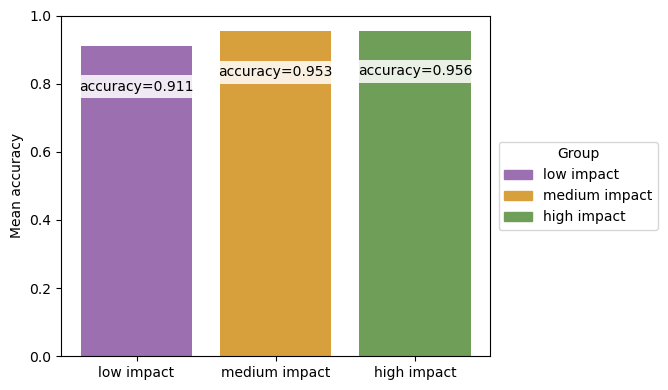

In [99]:
low_impact_prefixes = {'280', '281', '290', '291'}
medium_impact_prefixes = {'282', '292', '283', '293'}
high_impact_prefixes = {'284', '285', '294', '295'}


def impact_group(prefix):
    if prefix in low_impact_prefixes:
        return 'low impact'
    if prefix in medium_impact_prefixes:
        return 'medium impact'
    if prefix in high_impact_prefixes:
        return 'high impact'
    return np.nan


def impact_metrics(run_df):
    compare_impact_groups = run_df.copy()
    compare_impact_groups['comparison_group'] = compare_impact_groups['prefix3'].map(impact_group)
    compare_impact_groups = compare_impact_groups.dropna(subset=['comparison_group'])
    metrics = metrics_by(compare_impact_groups, 'comparison_group')
    return metrics.set_index('group').loc[['low impact', 'medium impact', 'high impact']].reset_index()

metrics_impact_groups_by_run = run_metrics(df, impact_metrics)
metrics_impact_groups_average = average_metrics(metrics_impact_groups_by_run)
metrics_impact_groups_average = order_groups(metrics_impact_groups_average, ['low impact', 'medium impact', 'high impact'])

display(metrics_impact_groups_by_run.round(4))
display_accuracy('Accuracy by run', metrics_impact_groups_by_run)
display(metrics_impact_groups_average)
display_accuracy('Average accuracy', metrics_impact_groups_average)
metrics_impact_groups_by_run.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_impact_groups_by_run.csv', index=False)
metrics_impact_groups_average.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_impact_groups_average.csv', index=False)

fig, ax = plt.subplots(figsize=(6.8, 4.0))
colors = {'low impact': '#9b6fb0', 'medium impact': '#d8a03d', 'high impact': '#6f9e59'}
bars = ax.bar(metrics_impact_groups_average['group'], metrics_impact_groups_average['accuracy_mean'], color=[colors[g] for g in metrics_impact_groups_average['group']])
ax.set_ylim(0, 1)
ax.set_ylabel('Mean accuracy')
ax.set_title('')
for bar, (_, row) in zip(bars, metrics_impact_groups_average.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, max(row['accuracy_mean'] - 0.12, 0.08), f"accuracy={row['accuracy_mean']:.3f}", ha='center', va='center', color='black', fontsize=10, bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3})
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colors[name], label=name) for name in ['low impact', 'medium impact', 'high impact']]
ax.legend(handles=legend_handles, title='Group', loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.tight_layout()
save_figure(fig, 'bruising_prediction_impact_accuracy_average.png')
plt.show()


## Statistical Test: Low, Medium, and High Impact


In [100]:
impact_test_df = df.copy()
impact_test_df['comparison_group'] = impact_test_df['prefix3'].map(impact_group)
impact_test_df = impact_test_df.dropna(subset=['comparison_group'])
impact_order = ['low impact', 'medium impact', 'high impact']

impact_counts, impact_pooled_test = test_correctness_groups(
    impact_test_df,
    'comparison_group',
    impact_order,
    'CNN low vs medium vs high impact correctness',
)
impact_run_tests = run_level_correctness_tests(
    impact_test_df,
    'comparison_group',
    impact_order,
    'CNN low vs medium vs high impact correctness',
)
impact_pairwise_tests = pairwise_correctness_tests(
    impact_test_df,
    'comparison_group',
    impact_order,
    'CNN pairwise impact correctness',
)

display(impact_counts)
display(impact_pooled_test.round(6))
display(impact_run_tests[['run', 'test', 'groups', 'chi2', 'dof', 'p_value']].round(6))
display(impact_pairwise_tests[['group_a', 'group_b', 'accuracy_a', 'accuracy_b', 'chi2', 'dof', 'p_value', 'fisher_exact_p_value', 'holm_adjusted_p_value']].round(6))
impact_counts.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_impact_groups_stat_counts.csv', index=False)
impact_pooled_test.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_impact_groups_stat_test_pooled.csv', index=False)
impact_run_tests.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_impact_groups_stat_tests_by_run.csv', index=False)
impact_pairwise_tests.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_impact_groups_stat_pairwise.csv', index=False)


,group,correct,incorrect,n,accuracy
0,low impact,350,34,384,0.9115
1,medium impact,366,18,384,0.9531
2,high impact,367,17,384,0.9557


,comparison,test,groups,chi2,dof,p_value
0,CNN low vs medium vs high impact correctness,chi-square test of independence,low impact vs medium impact vs high impact,8.417199,2,0.014867


,run,test,groups,chi2,dof,p_value
0,reports,chi-square test of independence,low impact vs medium impact vs high impact,12.996458,2,0.001506
1,reports_st1,chi-square test of independence,low impact vs medium impact vs high impact,4.159091,2,0.124987
2,reports_st2,chi-square test of independence,low impact vs medium impact vs high impact,0.130435,2,0.936864


,group_a,group_b,accuracy_a,accuracy_b,chi2,dof,p_value,fisher_exact_p_value,holm_adjusted_p_value
0,low impact,high impact,0.9115,0.9557,6.069735,1,0.013752,0.019612,0.041255
1,low impact,medium impact,0.9115,0.9531,5.280619,1,0.021564,0.030346,0.043128
2,medium impact,high impact,0.9531,0.9557,0.029936,1,0.862636,1.000000,0.862636


## Comparison: Low, Medium, and High Impact


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,low impact,128,114,14,80,0,14,34,48,34,0.8906,1.0000,0.7083,0.8293
1,reports,medium impact,128,122,6,79,1,5,43,48,44,0.9531,0.9773,0.8958,0.9348
2,reports,high impact,128,127,1,79,1,0,48,48,49,0.9922,0.9796,1.0000,0.9897
3,reports_st1,low impact,128,113,15,80,0,15,33,48,33,0.8828,1.0000,0.6875,0.8148
4,reports_st1,medium impact,128,122,6,78,2,4,44,48,46,0.9531,0.9565,0.9167,0.9362
5,reports_st1,high impact,128,117,11,69,11,0,48,48,59,0.9141,0.8136,1.0000,0.8972
6,reports_st2,low impact,128,123,5,80,0,5,43,48,43,0.9609,1.0000,0.8958,0.9451
7,reports_st2,medium impact,128,122,6,76,4,2,46,48,50,0.9531,0.9200,0.9583,0.9388
8,reports_st2,high impact,128,123,5,75,5,0,48,48,53,0.9609,0.9057,1.0000,0.9505


Accuracy by run


,run,group,accuracy
0,reports,low impact,0.8906
1,reports,medium impact,0.9531
2,reports,high impact,0.9922
3,reports_st1,low impact,0.8828
4,reports_st1,medium impact,0.9531
5,reports_st1,high impact,0.9141
6,reports_st2,low impact,0.9609
7,reports_st2,medium impact,0.9531
8,reports_st2,high impact,0.9609


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,low impact,3,128.0,0.0,128,128,116.6667,5.5076,113,123,...,1.0000,1.0000,0.7639,0.1147,0.6875,0.8958,0.8630,0.0714,0.8148,0.9451
1,medium impact,3,128.0,0.0,128,128,122.0000,0.0000,122,122,...,0.9200,0.9773,0.9236,0.0318,0.8958,0.9583,0.9366,0.0020,0.9348,0.9388
2,high impact,3,128.0,0.0,128,128,122.3333,5.0332,117,127,...,0.8136,0.9796,1.0000,0.0000,1.0000,1.0000,0.9458,0.0464,0.8972,0.9897


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,low impact,3,0.9115,0.8828,0.9609
1,medium impact,3,0.9531,0.9531,0.9531
2,high impact,3,0.9557,0.9141,0.9922


Files per group


,run,comparison_group,prefix3,n_files
0,reports,high impact,284,1
1,reports,high impact,285,1
2,reports,high impact,294,1
3,reports,high impact,295,1
4,reports,low impact,280,1
5,reports,low impact,281,1
6,reports,low impact,290,1
7,reports,low impact,291,1
8,reports,medium impact,282,1
9,reports,medium impact,283,1


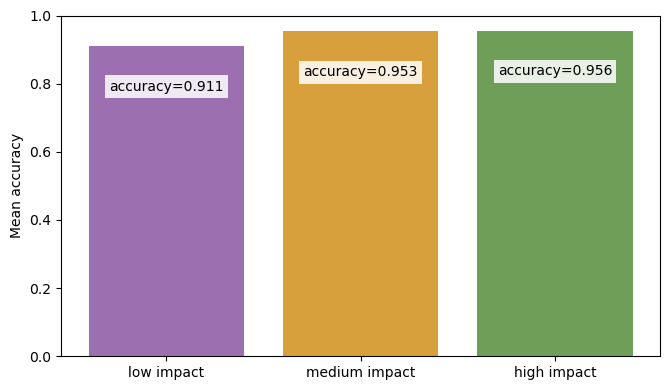

In [101]:
def impact_group_three_level(prefix):
    if prefix in low_impact_prefixes:
        return 'low impact'
    if prefix in medium_impact_prefixes:
        return 'medium impact'
    if prefix in high_impact_prefixes:
        return 'high impact'
    return np.nan


def three_group_metrics(run_df):
    compare_three_groups = run_df.copy()
    compare_three_groups['comparison_group'] = compare_three_groups['prefix3'].map(impact_group_three_level)
    compare_three_groups = compare_three_groups.dropna(subset=['comparison_group'])
    metrics = metrics_by(compare_three_groups, 'comparison_group')
    return metrics.set_index('group').loc[['low impact', 'medium impact', 'high impact']].reset_index()

metrics_three_groups_by_run = run_metrics(df, three_group_metrics)
metrics_three_groups_average = average_metrics(metrics_three_groups_by_run)
metrics_three_groups_average = order_groups(metrics_three_groups_average, ['low impact', 'medium impact', 'high impact'])

display(metrics_three_groups_by_run.round(4))
display_accuracy('Accuracy by run', metrics_three_groups_by_run)
display(metrics_three_groups_average)
display_accuracy('Average accuracy', metrics_three_groups_average)
metrics_three_groups_by_run.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_three_impact_groups_by_run.csv', index=False)
metrics_three_groups_average.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_three_impact_groups_average.csv', index=False)

print('Files per group')
compare_three_groups = df.copy()
compare_three_groups['comparison_group'] = compare_three_groups['prefix3'].map(impact_group_three_level)
compare_three_groups = compare_three_groups.dropna(subset=['comparison_group'])
display(compare_three_groups.drop_duplicates(['run', 'file']).groupby(['run', 'comparison_group', 'prefix3']).size().rename('n_files').reset_index())

fig, ax = plt.subplots(figsize=(6.8, 4.0))
colors = {'low impact': '#9b6fb0', 'medium impact': '#d8a03d', 'high impact': '#6f9e59'}
bars = ax.bar(metrics_three_groups_average['group'], metrics_three_groups_average['accuracy_mean'], color=[colors[g] for g in metrics_three_groups_average['group']])
ax.set_ylim(0, 1)
ax.set_ylabel('Mean accuracy')
ax.set_title('')
for bar, (_, row) in zip(bars, metrics_three_groups_average.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, max(row['accuracy_mean'] - 0.12, 0.08), f"accuracy={row['accuracy_mean']:.3f}", ha='center', va='center', color='black', fontsize=10, bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3})
plt.tight_layout()
save_figure(fig, 'bruising_prediction_three_impact_accuracy_average.png')
plt.show()


## Incorrect Predictions for Inspection


In [102]:
errors = df[~df['correct']].copy()
error_columns = ['run', 'file', 'microtec_id', 'timepoint', 'dataset', 'y_true_label', 'y_pred_label', 'y_true', 'y_pred']
display(errors[error_columns])
errors[error_columns].to_csv(TABLE_DIR / 'bruising_prediction_test_incorrect_predictions_by_run.csv', index=False)

error_frequency = (errors.groupby(['file', 'microtec_id', 'timepoint', 'dataset', 'y_true_label'], dropna=False).agg(n_missed_runs=('run', 'nunique'), missed_runs=('run', lambda s: ', '.join(sorted(s.unique())))).reset_index().sort_values(['n_missed_runs', 'file', 'timepoint', 'dataset'], ascending=[False, True, True, True]))
display(error_frequency)
error_frequency.to_csv(TABLE_DIR / 'bruising_prediction_test_incorrect_predictions_average_summary.csv', index=False)
print('Incorrect predictions across runs:', len(errors), 'of', len(df))


,run,file,microtec_id,timepoint,dataset,y_true_label,y_pred_label,y_true,y_pred
136,reports,MICROTEC_29100_processed_boxes.h5,29100,t1,bruised1,damaged,sound,1,0
144,reports,MICROTEC_29100_processed_boxes.h5,29100,t2,bruised1,damaged,sound,1,0
147,reports,MICROTEC_29100_processed_boxes.h5,29100,t2,bruised4,damaged,sound,1,0
176,reports,MICROTEC_28305_processed_boxes.h5,28305,t2,bruised1,damaged,sound,1,0
200,reports,MICROTEC_28009_processed_boxes.h5,28009,t1,bruised1,damaged,sound,1,0
...,...,...,...,...,...,...,...,...,...
1036,reports_st2,MICROTEC_28507_processed_boxes.h5,28507,t1,sound1,sound,damaged,0,1
1052,reports_st2,MICROTEC_28507_processed_boxes.h5,28507,t3,sound1,sound,damaged,0,1
1090,reports_st2,MICROTEC_29309_processed_boxes.h5,29309,t0,bruised3,sound,damaged,0,1
1104,reports_st2,MICROTEC_29309_processed_boxes.h5,29309,t2,bruised1,damaged,sound,1,0


,file,microtec_id,timepoint,dataset,y_true_label,n_missed_runs,missed_runs
0,MICROTEC_28009_processed_boxes.h5,28009,t1,bruised1,damaged,3,"reports, reports_st1, reports_st2"
3,MICROTEC_28009_processed_boxes.h5,28009,t1,bruised4,damaged,3,"reports, reports_st1, reports_st2"
4,MICROTEC_28009_processed_boxes.h5,28009,t2,bruised1,damaged,3,"reports, reports_st1, reports_st2"
19,MICROTEC_28507_processed_boxes.h5,28507,t0,bruised1,sound,3,"reports, reports_st1, reports_st2"
26,MICROTEC_29006_processed_boxes.h5,29006,t1,bruised3,damaged,3,"reports, reports_st1, reports_st2"
35,MICROTEC_29207_processed_boxes.h5,29207,t1,bruised3,damaged,3,"reports, reports_st1, reports_st2"
2,MICROTEC_28009_processed_boxes.h5,28009,t1,bruised3,damaged,2,"reports, reports_st1"
5,MICROTEC_28009_processed_boxes.h5,28009,t2,bruised2,damaged,2,"reports, reports_st1"
6,MICROTEC_28009_processed_boxes.h5,28009,t2,bruised3,damaged,2,"reports, reports_st1"
8,MICROTEC_28009_processed_boxes.h5,28009,t3,bruised1,damaged,2,"reports, reports_st1"


Incorrect predictions across runs: 69 of 1152


# PCA-SVM Test Result Average Analysis

This section repeats the same averaged test-result analyses for `pca_svm_test_predictions.csv`. It uses `data/splits` for the split sample summaries.


In [103]:
svm_df = load_predictions('pca_svm_test_predictions.csv')

svm_run_summary = svm_df.groupby('run').agg(
    rows=('sample_id', 'size'),
    files=('file', 'nunique'),
    timepoints=('timepoint', lambda s: ', '.join(sorted(s.astype(str).unique()))),
).reset_index()

display(svm_df.head())
display(svm_run_summary)
print('Runs:', ', '.join(REPORT_RUNS))
print('Total rows across runs:', len(svm_df))


,path,file,group,timepoint,dataset,y,label,box_shape,crop_shape,bands,...,y_pred,y_true_label,y_pred_label,run,source_csv,sample_id,microtec_id,prefix2,prefix3,correct
0,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_28009_processed_boxes.h5,SWIR_t0,t0,bruised1,0,sound,"(160, 160)","(10, 10)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_28009_processed_boxes.h5 | t0 | bruised1,28009,28,280,True
1,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_28009_processed_boxes.h5,SWIR_t0,t0,bruised2,0,sound,"(160, 160)","(10, 10)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_28009_processed_boxes.h5 | t0 | bruised2,28009,28,280,True
2,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_28009_processed_boxes.h5,SWIR_t0,t0,bruised3,0,sound,"(160, 160)","(10, 10)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_28009_processed_boxes.h5 | t0 | bruised3,28009,28,280,True
3,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_28009_processed_boxes.h5,SWIR_t0,t0,bruised4,0,sound,"(160, 160)","(10, 10)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_28009_processed_boxes.h5 | t0 | bruised4,28009,28,280,True
4,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_28009_processed_boxes.h5,SWIR_t0,t0,sound1,0,sound,"(160, 160)","(10, 10)",220,...,0,sound,sound,reports,/home/emahan/sysops/HIPPA/hanif/bruising_detec...,MICROTEC_28009_processed_boxes.h5 | t0 | sound1,28009,28,280,True


,run,rows,files,timepoints
0,reports,384,12,"t0, t1, t2, t3"
1,reports_st1,384,12,"t0, t1, t2, t3"
2,reports_st2,384,12,"t0, t1, t2, t3"


Runs: reports, reports_st1, reports_st2
Total rows across runs: 1152


## PCA-SVM Train/Validation/Test Sample Counts


In [104]:
SVM_SPLIT_SAMPLE_CSVS = {
    'train': PROJECT_ROOT / 'data' / 'splits' / 'train_samples.csv',
    'val': PROJECT_ROOT / 'data' / 'splits' / 'val_samples.csv',
    'test': PROJECT_ROOT / 'data' / 'splits' / 'test_samples.csv',
}

svm_split_rows = []
for split, path in SVM_SPLIT_SAMPLE_CSVS.items():
    split_df = pd.read_csv(path)
    svm_split_rows.append({
        'split': split,
        'n_files': split_df['file'].nunique(),
        'n_samples': len(split_df),
        'n_sound': int((split_df['y'] == 0).sum()),
        'n_bruised': int((split_df['y'] == 1).sum()),
    })

svm_split_summary = pd.DataFrame(svm_split_rows)
svm_total_files = int(svm_split_summary['n_files'].sum())
svm_total_samples = int(svm_split_summary['n_samples'].sum())
svm_total_sound = int(svm_split_summary['n_sound'].sum())
svm_total_bruised = int(svm_split_summary['n_bruised'].sum())
svm_split_summary['file_ratio'] = (svm_split_summary['n_files'] / svm_total_files).round(4)
svm_split_summary['sample_ratio'] = (svm_split_summary['n_samples'] / svm_total_samples).round(4)
svm_split_summary = pd.concat([svm_split_summary, pd.DataFrame([{'split': 'total', 'n_files': svm_total_files, 'n_samples': svm_total_samples, 'n_sound': svm_total_sound, 'n_bruised': svm_total_bruised, 'file_ratio': 1.0, 'sample_ratio': 1.0}])], ignore_index=True)

display(svm_split_summary)
svm_split_summary.to_csv(TABLE_DIR / 'pca_svm_prediction_split_sample_summary.csv', index=False)


,split,n_files,n_samples,n_sound,n_bruised,file_ratio,sample_ratio
0,train,94,3008,1880,1128,0.7966,0.7966
1,val,12,384,240,144,0.1017,0.1017
2,test,12,384,240,144,0.1017,0.1017
3,total,118,3776,2360,1416,1.0000,1.0000


## PCA-SVM Overall Confusion Matrix


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,overall,384,366,18,236,4,14,130,144,134,0.9531,0.9701,0.9028,0.9353
1,reports_st1,overall,384,366,18,236,4,14,130,144,134,0.9531,0.9701,0.9028,0.9353
2,reports_st2,overall,384,366,18,236,4,14,130,144,134,0.9531,0.9701,0.9028,0.9353


Accuracy by run


,run,group,accuracy
0,reports,overall,0.9531
1,reports_st1,overall,0.9531
2,reports_st2,overall,0.9531


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,overall,3,384.0,0.0,384,384,366.0,0.0,366,366,...,0.9701,0.9701,0.9028,0.0,0.9028,0.9028,0.9353,0.0,0.9353,0.9353


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,overall,3,0.9531,0.9531,0.9531


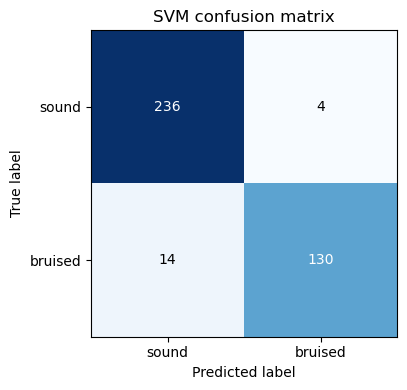

In [105]:
svm_overall_by_run = run_metrics(svm_df, lambda run_df: pd.DataFrame([metric_row(run_df, 'overall')]))
svm_overall_average = average_metrics(svm_overall_by_run)

display(svm_overall_by_run.round(4))
display_accuracy('Accuracy by run', svm_overall_by_run)
display(svm_overall_average)
display_accuracy('Average accuracy', svm_overall_average)
svm_overall_by_run.to_csv(TABLE_DIR / 'pca_svm_test_overall_metrics_by_run.csv', index=False)
svm_overall_average.to_csv(TABLE_DIR / 'pca_svm_test_overall_metrics_average.csv', index=False)

svm_mean_cm = svm_overall_by_run[['true_negative', 'false_positive', 'false_negative', 'true_positive']].mean().to_numpy().reshape(2, 2)
fig, ax = plt.subplots(figsize=(4.5, 4))
plot_confusion(svm_mean_cm, 'SVM confusion matrix', ax=ax)
plt.tight_layout()
save_figure(fig, 'pca_svm_overall_confusion_average.png')
plt.show()


## Statistical Test: Overall CNN vs PCA-SVM Accuracy


In [106]:
overall_model_counts, overall_model_test = compare_paired_model_correctness(
    df,
    svm_df,
    'Overall CNN vs PCA-SVM correctness',
)

display(overall_model_counts)
display(overall_model_test.round(6))
overall_model_counts.to_csv(TABLE_DIR / 'overall_cnn_vs_pca_svm_stat_counts.csv', index=False)
overall_model_test.to_csv(TABLE_DIR / 'overall_cnn_vs_pca_svm_stat_test.csv', index=False)


,comparison,n_matched,both_correct,cnn_only_correct,svm_only_correct,both_incorrect,cnn_accuracy,svm_accuracy
0,Overall CNN vs PCA-SVM correctness,1152,1046,37,52,17,0.9401,0.9531


,comparison,test,n_discordant,cnn_only_correct,svm_only_correct,exact_p_value,mcnemar_chi2_continuity,mcnemar_chi2_p_value
0,Overall CNN vs PCA-SVM correctness,McNemar exact binomial test on paired correctness,89,37,52,0.137368,2.202247,0.13781


## PCA-SVM Accuracy, Precision, Recall by Timepoint


In [107]:
svm_timepoint_metrics_by_run = run_metrics(svm_df, lambda run_df: metrics_by(run_df, 'timepoint'))
svm_timepoint_metrics_average = average_metrics(svm_timepoint_metrics_by_run)

display(svm_timepoint_metrics_by_run.round(4))
display_accuracy('Accuracy by run', svm_timepoint_metrics_by_run)
display(svm_timepoint_metrics_average)
display_accuracy('Average accuracy', svm_timepoint_metrics_average)
svm_timepoint_metrics_by_run.to_csv(TABLE_DIR / 'pca_svm_test_metrics_by_timepoint_by_run.csv', index=False)
svm_timepoint_metrics_average.to_csv(TABLE_DIR / 'pca_svm_test_metrics_by_timepoint_average.csv', index=False)


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,t0,96,94,2,94,2,0,0,0,2,0.9792,0.0000,0.0000,0.0000
1,reports,t1,96,87,9,47,1,8,40,48,41,0.9062,0.9756,0.8333,0.8989
2,reports,t2,96,91,5,48,0,5,43,48,43,0.9479,1.0000,0.8958,0.9451
3,reports,t3,96,94,2,47,1,1,47,48,48,0.9792,0.9792,0.9792,0.9792
4,reports_st1,t0,96,94,2,94,2,0,0,0,2,0.9792,0.0000,0.0000,0.0000
5,reports_st1,t1,96,87,9,47,1,8,40,48,41,0.9062,0.9756,0.8333,0.8989
6,reports_st1,t2,96,91,5,48,0,5,43,48,43,0.9479,1.0000,0.8958,0.9451
7,reports_st1,t3,96,94,2,47,1,1,47,48,48,0.9792,0.9792,0.9792,0.9792
8,reports_st2,t0,96,94,2,94,2,0,0,0,2,0.9792,0.0000,0.0000,0.0000
9,reports_st2,t1,96,87,9,47,1,8,40,48,41,0.9062,0.9756,0.8333,0.8989


Accuracy by run


,run,group,accuracy
0,reports,t0,0.9792
1,reports,t1,0.9062
2,reports,t2,0.9479
3,reports,t3,0.9792
4,reports_st1,t0,0.9792
5,reports_st1,t1,0.9062
6,reports_st1,t2,0.9479
7,reports_st1,t3,0.9792
8,reports_st2,t0,0.9792
9,reports_st2,t1,0.9062


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,t0,3,96.0,0.0,96,96,94.0,0.0,94,94,...,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0000
1,t1,3,96.0,0.0,96,96,87.0,0.0,87,87,...,0.9756,0.9756,0.8333,0.0,0.8333,0.8333,0.8989,0.0,0.8989,0.8989
2,t2,3,96.0,0.0,96,96,91.0,0.0,91,91,...,1.0000,1.0000,0.8958,0.0,0.8958,0.8958,0.9451,0.0,0.9451,0.9451
3,t3,3,96.0,0.0,96,96,94.0,0.0,94,94,...,0.9792,0.9792,0.9792,0.0,0.9792,0.9792,0.9792,0.0,0.9792,0.9792


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,t0,3,0.9792,0.9792,0.9792
1,t1,3,0.9062,0.9062,0.9062
2,t2,3,0.9479,0.9479,0.9479
3,t3,3,0.9792,0.9792,0.9792


## PCA-SVM Confusion Matrix per Timepoint


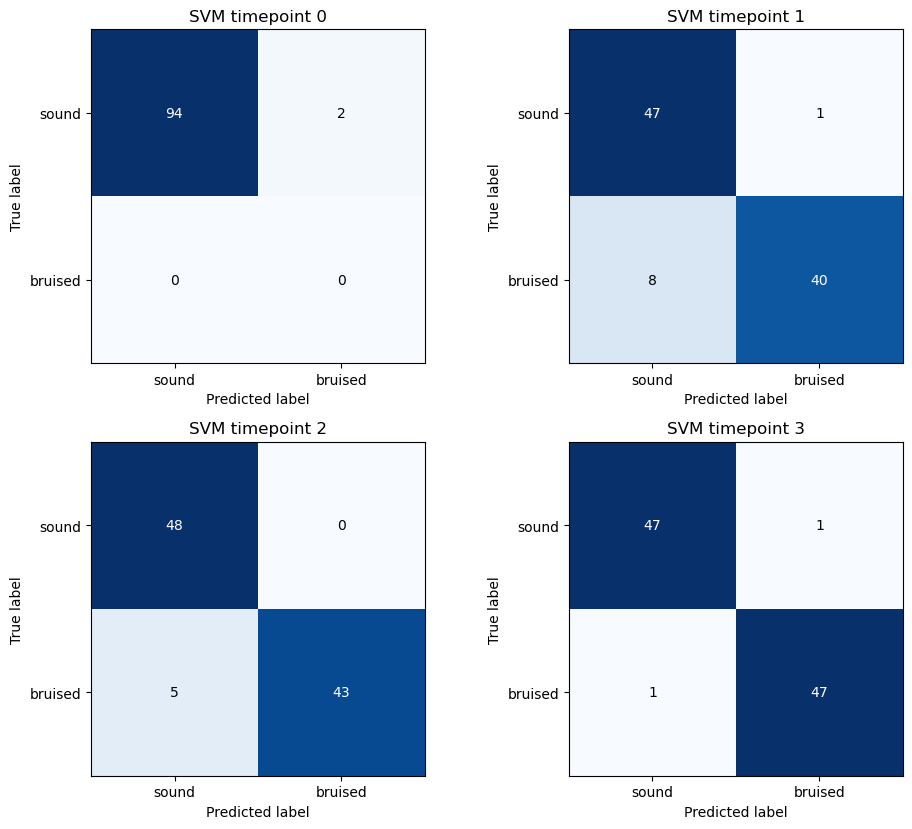

In [108]:
svm_timepoints = sorted(svm_df['timepoint'].astype(str).unique())
ncols = 2
nrows = int(np.ceil(len(svm_timepoints) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, tp in zip(axes, svm_timepoints):
    g = svm_timepoint_metrics_by_run[svm_timepoint_metrics_by_run['group'].astype(str) == tp]
    cm = g[['true_negative', 'false_positive', 'false_negative', 'true_positive']].mean().to_numpy().reshape(2, 2)
    plot_confusion(cm, f"SVM timepoint {str(tp).lstrip('t')}", ax=ax)

for ax in axes[len(svm_timepoints):]:
    ax.axis('off')

plt.tight_layout()
save_figure(fig, 'pca_svm_timepoint_confusion_average.png')
plt.show()


## PCA-SVM Comparison: Warm vs Cold Condition


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,warm,192,184,8,117,3,5,67,72,70,0.9583,0.9571,0.9306,0.9437
1,reports,cold,192,182,10,119,1,9,63,72,64,0.9479,0.9844,0.8750,0.9265
2,reports_st1,warm,192,184,8,117,3,5,67,72,70,0.9583,0.9571,0.9306,0.9437
3,reports_st1,cold,192,182,10,119,1,9,63,72,64,0.9479,0.9844,0.8750,0.9265
4,reports_st2,warm,192,184,8,117,3,5,67,72,70,0.9583,0.9571,0.9306,0.9437
5,reports_st2,cold,192,182,10,119,1,9,63,72,64,0.9479,0.9844,0.8750,0.9265


Accuracy by run


,run,group,accuracy
0,reports,warm,0.9583
1,reports,cold,0.9479
2,reports_st1,warm,0.9583
3,reports_st1,cold,0.9479
4,reports_st2,warm,0.9583
5,reports_st2,cold,0.9479


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,cold,3,192.0,0.0,192,192,182.0,0.0,182,182,...,0.9844,0.9844,0.8750,0.0,0.8750,0.8750,0.9265,0.0,0.9265,0.9265
1,warm,3,192.0,0.0,192,192,184.0,0.0,184,184,...,0.9571,0.9571,0.9306,0.0,0.9306,0.9306,0.9437,0.0,0.9437,0.9437


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,cold,3,0.9479,0.9479,0.9479
1,warm,3,0.9583,0.9583,0.9583


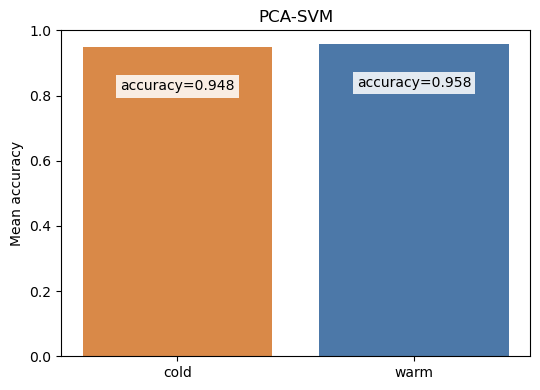

In [109]:
svm_metrics_warm_cold_by_run = run_metrics(svm_df, warm_cold_metrics)
svm_metrics_warm_cold_average = average_metrics(svm_metrics_warm_cold_by_run)

display(svm_metrics_warm_cold_by_run.round(4))
display_accuracy('Accuracy by run', svm_metrics_warm_cold_by_run)
display(svm_metrics_warm_cold_average)
display_accuracy('Average accuracy', svm_metrics_warm_cold_average)
svm_metrics_warm_cold_by_run.to_csv(TABLE_DIR / 'pca_svm_test_compare_warm_cold_by_run.csv', index=False)
svm_metrics_warm_cold_average.to_csv(TABLE_DIR / 'pca_svm_test_compare_warm_cold_average.csv', index=False)

fig, ax = plt.subplots(figsize=(5.5, 4.0))
bars = ax.bar(svm_metrics_warm_cold_average['group'], svm_metrics_warm_cold_average['accuracy_mean'], color=['#d98948', '#4c78a8'])
ax.set_ylim(0, 1)
ax.set_ylabel('Mean accuracy')
ax.set_title('PCA-SVM')
for bar, (_, row) in zip(bars, svm_metrics_warm_cold_average.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, max(row['accuracy_mean'] - 0.12, 0.08), f"accuracy={row['accuracy_mean']:.3f}", ha='center', va='center', color='black', fontsize=10, bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3})
plt.tight_layout()
save_figure(fig, 'pca_svm_warm_cold_accuracy_average.png')
plt.show()


## PCA-SVM Statistical Test: Warm vs Cold Condition


In [110]:
svm_warm_cold_test_df = svm_df[svm_df['prefix2'].isin(['28', '29'])].copy()
svm_warm_cold_test_df['comparison_group'] = svm_warm_cold_test_df['prefix2'].map({'28': 'warm', '29': 'cold'})

svm_warm_cold_counts, svm_warm_cold_pooled_test = test_correctness_groups(
    svm_warm_cold_test_df,
    'comparison_group',
    ['warm', 'cold'],
    'PCA-SVM warm vs cold correctness',
)
svm_warm_cold_run_tests = run_level_correctness_tests(
    svm_warm_cold_test_df,
    'comparison_group',
    ['warm', 'cold'],
    'PCA-SVM warm vs cold correctness',
)

display(svm_warm_cold_counts)
display(svm_warm_cold_pooled_test.round(6))
display(svm_warm_cold_run_tests[['run', 'test', 'groups', 'chi2', 'dof', 'p_value', 'fisher_exact_p_value']].round(6))
svm_warm_cold_counts.to_csv(TABLE_DIR / 'pca_svm_test_compare_warm_cold_stat_counts.csv', index=False)
svm_warm_cold_pooled_test.to_csv(TABLE_DIR / 'pca_svm_test_compare_warm_cold_stat_test_pooled.csv', index=False)
svm_warm_cold_run_tests.to_csv(TABLE_DIR / 'pca_svm_test_compare_warm_cold_stat_tests_by_run.csv', index=False)


,group,correct,incorrect,n,accuracy
0,warm,552,24,576,0.9583
1,cold,546,30,576,0.9479


,comparison,test,groups,chi2,dof,p_value,fisher_exact_oddsratio,fisher_exact_p_value
0,PCA-SVM warm vs cold correctness,chi-square test of independence,warm vs cold,0.699454,1,0.402967,1.263736,0.48617


,run,test,groups,chi2,dof,p_value,fisher_exact_p_value
0,reports,chi-square test of independence,warm vs cold,0.233151,1,0.629197,0.810029
1,reports_st1,chi-square test of independence,warm vs cold,0.233151,1,0.629197,0.810029
2,reports_st2,chi-square test of independence,warm vs cold,0.233151,1,0.629197,0.810029


## PCA-SVM Comparison: Low, Medium, and High Impact


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,low impact,128,121,7,80,0,7,41,48,41,0.9453,1.0000,0.8542,0.9213
1,reports,medium impact,128,120,8,78,2,6,42,48,44,0.9375,0.9545,0.8750,0.9130
2,reports,high impact,128,125,3,78,2,1,47,48,49,0.9766,0.9592,0.9792,0.9691
3,reports_st1,low impact,128,121,7,80,0,7,41,48,41,0.9453,1.0000,0.8542,0.9213
4,reports_st1,medium impact,128,120,8,78,2,6,42,48,44,0.9375,0.9545,0.8750,0.9130
5,reports_st1,high impact,128,125,3,78,2,1,47,48,49,0.9766,0.9592,0.9792,0.9691
6,reports_st2,low impact,128,121,7,80,0,7,41,48,41,0.9453,1.0000,0.8542,0.9213
7,reports_st2,medium impact,128,120,8,78,2,6,42,48,44,0.9375,0.9545,0.8750,0.9130
8,reports_st2,high impact,128,125,3,78,2,1,47,48,49,0.9766,0.9592,0.9792,0.9691


Accuracy by run


,run,group,accuracy
0,reports,low impact,0.9453
1,reports,medium impact,0.9375
2,reports,high impact,0.9766
3,reports_st1,low impact,0.9453
4,reports_st1,medium impact,0.9375
5,reports_st1,high impact,0.9766
6,reports_st2,low impact,0.9453
7,reports_st2,medium impact,0.9375
8,reports_st2,high impact,0.9766


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,low impact,3,128.0,0.0,128,128,121.0,0.0,121,121,...,1.0000,1.0000,0.8542,0.0,0.8542,0.8542,0.9213,0.0,0.9213,0.9213
1,medium impact,3,128.0,0.0,128,128,120.0,0.0,120,120,...,0.9545,0.9545,0.8750,0.0,0.8750,0.8750,0.9130,0.0,0.9130,0.9130
2,high impact,3,128.0,0.0,128,128,125.0,0.0,125,125,...,0.9592,0.9592,0.9792,0.0,0.9792,0.9792,0.9691,0.0,0.9691,0.9691


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,low impact,3,0.9453,0.9453,0.9453
1,medium impact,3,0.9375,0.9375,0.9375
2,high impact,3,0.9766,0.9766,0.9766


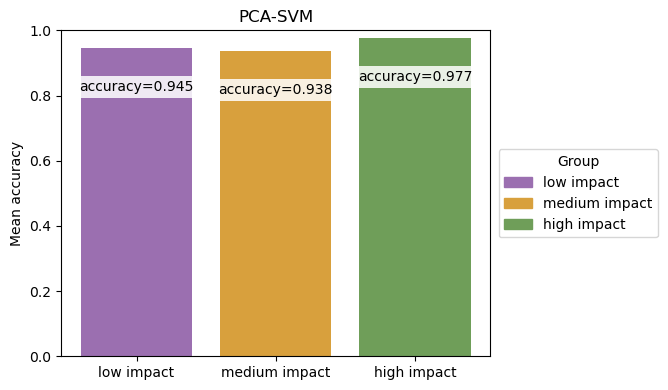

In [111]:
svm_metrics_impact_groups_by_run = run_metrics(svm_df, impact_metrics)
svm_metrics_impact_groups_average = average_metrics(svm_metrics_impact_groups_by_run)
svm_metrics_impact_groups_average = order_groups(svm_metrics_impact_groups_average, ['low impact', 'medium impact', 'high impact'])

display(svm_metrics_impact_groups_by_run.round(4))
display_accuracy('Accuracy by run', svm_metrics_impact_groups_by_run)
display(svm_metrics_impact_groups_average)
display_accuracy('Average accuracy', svm_metrics_impact_groups_average)
svm_metrics_impact_groups_by_run.to_csv(TABLE_DIR / 'pca_svm_test_compare_impact_groups_by_run.csv', index=False)
svm_metrics_impact_groups_average.to_csv(TABLE_DIR / 'pca_svm_test_compare_impact_groups_average.csv', index=False)

fig, ax = plt.subplots(figsize=(6.8, 4.0))
colors = {'low impact': '#9b6fb0', 'medium impact': '#d8a03d', 'high impact': '#6f9e59'}
bars = ax.bar(svm_metrics_impact_groups_average['group'], svm_metrics_impact_groups_average['accuracy_mean'], color=[colors[g] for g in svm_metrics_impact_groups_average['group']])
ax.set_ylim(0, 1)
ax.set_ylabel('Mean accuracy')
ax.set_title('PCA-SVM')
for bar, (_, row) in zip(bars, svm_metrics_impact_groups_average.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, max(row['accuracy_mean'] - 0.12, 0.08), f"accuracy={row['accuracy_mean']:.3f}", ha='center', va='center', color='black', fontsize=10, bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3})
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colors[name], label=name) for name in ['low impact', 'medium impact', 'high impact']]
ax.legend(handles=legend_handles, title='Group', loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.tight_layout()
save_figure(fig, 'pca_svm_impact_accuracy_average.png')
plt.show()


## PCA-SVM Statistical Test: Low, Medium, and High Impact


In [112]:
svm_impact_test_df = svm_df.copy()
svm_impact_test_df['comparison_group'] = svm_impact_test_df['prefix3'].map(impact_group)
svm_impact_test_df = svm_impact_test_df.dropna(subset=['comparison_group'])
impact_order = ['low impact', 'medium impact', 'high impact']

svm_impact_counts, svm_impact_pooled_test = test_correctness_groups(
    svm_impact_test_df,
    'comparison_group',
    impact_order,
    'PCA-SVM low vs medium vs high impact correctness',
)
svm_impact_run_tests = run_level_correctness_tests(
    svm_impact_test_df,
    'comparison_group',
    impact_order,
    'PCA-SVM low vs medium vs high impact correctness',
)
svm_impact_pairwise_tests = pairwise_correctness_tests(
    svm_impact_test_df,
    'comparison_group',
    impact_order,
    'PCA-SVM pairwise impact correctness',
)

display(svm_impact_counts)
display(svm_impact_pooled_test.round(6))
display(svm_impact_run_tests[['run', 'test', 'groups', 'chi2', 'dof', 'p_value']].round(6))
display(svm_impact_pairwise_tests[['group_a', 'group_b', 'accuracy_a', 'accuracy_b', 'chi2', 'dof', 'p_value', 'fisher_exact_p_value', 'holm_adjusted_p_value']].round(6))
svm_impact_counts.to_csv(TABLE_DIR / 'pca_svm_test_compare_impact_groups_stat_counts.csv', index=False)
svm_impact_pooled_test.to_csv(TABLE_DIR / 'pca_svm_test_compare_impact_groups_stat_test_pooled.csv', index=False)
svm_impact_run_tests.to_csv(TABLE_DIR / 'pca_svm_test_compare_impact_groups_stat_tests_by_run.csv', index=False)
svm_impact_pairwise_tests.to_csv(TABLE_DIR / 'pca_svm_test_compare_impact_groups_stat_pairwise.csv', index=False)


,group,correct,incorrect,n,accuracy
0,low impact,363,21,384,0.9453
1,medium impact,360,24,384,0.9375
2,high impact,375,9,384,0.9766


,comparison,test,groups,chi2,dof,p_value
0,PCA-SVM low vs medium vs high impact correctness,chi-square test of independence,low impact vs medium impact vs high impact,7.344262,2,0.025422


,run,test,groups,chi2,dof,p_value
0,reports,chi-square test of independence,low impact vs medium impact vs high impact,2.448087,2,0.294039
1,reports_st1,chi-square test of independence,low impact vs medium impact vs high impact,2.448087,2,0.294039
2,reports_st2,chi-square test of independence,low impact vs medium impact vs high impact,2.448087,2,0.294039


,group_a,group_b,accuracy_a,accuracy_b,chi2,dof,p_value,fisher_exact_p_value,holm_adjusted_p_value
0,medium impact,high impact,0.9375,0.9766,7.124304,1,0.007605,0.011631,0.022814
1,low impact,high impact,0.9453,0.9766,4.995122,1,0.025419,0.038810,0.050838
2,low impact,medium impact,0.9453,0.9375,0.212448,1,0.644855,0.758991,0.644855


## PCA-SVM Comparison: Low, Medium, and High Impact


,run,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,reports,low impact,128,121,7,80,0,7,41,48,41,0.9453,1.0000,0.8542,0.9213
1,reports,medium impact,128,120,8,78,2,6,42,48,44,0.9375,0.9545,0.8750,0.9130
2,reports,high impact,128,125,3,78,2,1,47,48,49,0.9766,0.9592,0.9792,0.9691
3,reports_st1,low impact,128,121,7,80,0,7,41,48,41,0.9453,1.0000,0.8542,0.9213
4,reports_st1,medium impact,128,120,8,78,2,6,42,48,44,0.9375,0.9545,0.8750,0.9130
5,reports_st1,high impact,128,125,3,78,2,1,47,48,49,0.9766,0.9592,0.9792,0.9691
6,reports_st2,low impact,128,121,7,80,0,7,41,48,41,0.9453,1.0000,0.8542,0.9213
7,reports_st2,medium impact,128,120,8,78,2,6,42,48,44,0.9375,0.9545,0.8750,0.9130
8,reports_st2,high impact,128,125,3,78,2,1,47,48,49,0.9766,0.9592,0.9792,0.9691


Accuracy by run


,run,group,accuracy
0,reports,low impact,0.9453
1,reports,medium impact,0.9375
2,reports,high impact,0.9766
3,reports_st1,low impact,0.9453
4,reports_st1,medium impact,0.9375
5,reports_st1,high impact,0.9766
6,reports_st2,low impact,0.9453
7,reports_st2,medium impact,0.9375
8,reports_st2,high impact,0.9766


,group,n_runs,n_mean,n_std,n_min,n_max,correct_mean,correct_std,correct_min,correct_max,...,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,f1_mean,f1_std,f1_min,f1_max
0,low impact,3,128.0,0.0,128,128,121.0,0.0,121,121,...,1.0000,1.0000,0.8542,0.0,0.8542,0.8542,0.9213,0.0,0.9213,0.9213
1,medium impact,3,128.0,0.0,128,128,120.0,0.0,120,120,...,0.9545,0.9545,0.8750,0.0,0.8750,0.8750,0.9130,0.0,0.9130,0.9130
2,high impact,3,128.0,0.0,128,128,125.0,0.0,125,125,...,0.9592,0.9592,0.9792,0.0,0.9792,0.9792,0.9691,0.0,0.9691,0.9691


Average accuracy


,group,n_runs,accuracy_mean,accuracy_min,accuracy_max
0,low impact,3,0.9453,0.9453,0.9453
1,medium impact,3,0.9375,0.9375,0.9375
2,high impact,3,0.9766,0.9766,0.9766


Files per group


,run,comparison_group,prefix3,n_files
0,reports,high impact,284,1
1,reports,high impact,285,1
2,reports,high impact,294,1
3,reports,high impact,295,1
4,reports,low impact,280,1
5,reports,low impact,281,1
6,reports,low impact,290,1
7,reports,low impact,291,1
8,reports,medium impact,282,1
9,reports,medium impact,283,1


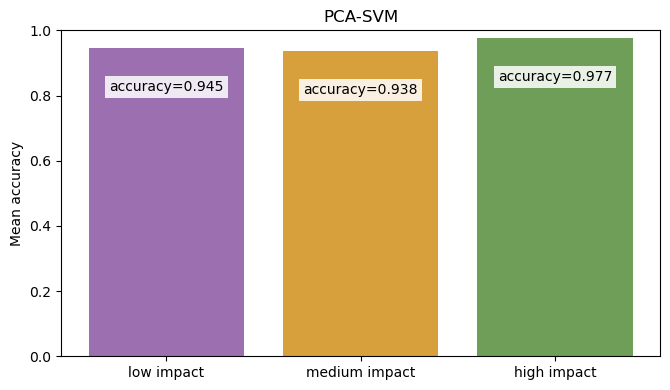

In [113]:
svm_metrics_three_groups_by_run = run_metrics(svm_df, three_group_metrics)
svm_metrics_three_groups_average = average_metrics(svm_metrics_three_groups_by_run)
svm_metrics_three_groups_average = order_groups(svm_metrics_three_groups_average, ['low impact', 'medium impact', 'high impact'])

display(svm_metrics_three_groups_by_run.round(4))
display_accuracy('Accuracy by run', svm_metrics_three_groups_by_run)
display(svm_metrics_three_groups_average)
display_accuracy('Average accuracy', svm_metrics_three_groups_average)
svm_metrics_three_groups_by_run.to_csv(TABLE_DIR / 'pca_svm_test_compare_three_impact_groups_by_run.csv', index=False)
svm_metrics_three_groups_average.to_csv(TABLE_DIR / 'pca_svm_test_compare_three_impact_groups_average.csv', index=False)

print('Files per group')
svm_compare_three_groups = svm_df.copy()
svm_compare_three_groups['comparison_group'] = svm_compare_three_groups['prefix3'].map(impact_group_three_level)
svm_compare_three_groups = svm_compare_three_groups.dropna(subset=['comparison_group'])
display(svm_compare_three_groups.drop_duplicates(['run', 'file']).groupby(['run', 'comparison_group', 'prefix3']).size().rename('n_files').reset_index())

fig, ax = plt.subplots(figsize=(6.8, 4.0))
colors = {'low impact': '#9b6fb0', 'medium impact': '#d8a03d', 'high impact': '#6f9e59'}
bars = ax.bar(svm_metrics_three_groups_average['group'], svm_metrics_three_groups_average['accuracy_mean'], color=[colors[g] for g in svm_metrics_three_groups_average['group']])
ax.set_ylim(0, 1)
ax.set_ylabel('Mean accuracy')
ax.set_title('PCA-SVM')
for bar, (_, row) in zip(bars, svm_metrics_three_groups_average.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, max(row['accuracy_mean'] - 0.12, 0.08), f"accuracy={row['accuracy_mean']:.3f}", ha='center', va='center', color='black', fontsize=10, bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3})
plt.tight_layout()
save_figure(fig, 'pca_svm_three_impact_accuracy_average.png')
plt.show()


## PCA-SVM Incorrect Predictions for Inspection


In [114]:
svm_errors = svm_df[~svm_df['correct']].copy()
svm_error_columns = ['run', 'file', 'microtec_id', 'timepoint', 'dataset', 'y_true_label', 'y_pred_label', 'y_true', 'y_pred']
display(svm_errors[svm_error_columns])
svm_errors[svm_error_columns].to_csv(TABLE_DIR / 'pca_svm_test_incorrect_predictions_by_run.csv', index=False)

svm_error_frequency = (svm_errors.groupby(['file', 'microtec_id', 'timepoint', 'dataset', 'y_true_label'], dropna=False).agg(n_missed_runs=('run', 'nunique'), missed_runs=('run', lambda s: ', '.join(sorted(s.unique())))).reset_index().sort_values(['n_missed_runs', 'file', 'timepoint', 'dataset'], ascending=[False, True, True, True]))
display(svm_error_frequency)
svm_error_frequency.to_csv(TABLE_DIR / 'pca_svm_test_incorrect_predictions_average_summary.csv', index=False)
print('Incorrect predictions across runs:', len(svm_errors), 'of', len(svm_df))


,run,file,microtec_id,timepoint,dataset,y_true_label,y_pred_label,y_true,y_pred
11,reports,MICROTEC_28009_processed_boxes.h5,28009,t1,bruised4,damaged,sound,1,0
68,reports,MICROTEC_28206_processed_boxes.h5,28206,t0,sound1,sound,damaged,0,1
75,reports,MICROTEC_28206_processed_boxes.h5,28206,t1,bruised4,damaged,sound,1,0
76,reports,MICROTEC_28206_processed_boxes.h5,28206,t1,sound1,sound,damaged,0,1
83,reports,MICROTEC_28206_processed_boxes.h5,28206,t2,bruised4,damaged,sound,1,0
106,reports,MICROTEC_28305_processed_boxes.h5,28305,t1,bruised3,damaged,sound,1,0
163,reports,MICROTEC_28507_processed_boxes.h5,28507,t0,bruised4,sound,damaged,0,1
168,reports,MICROTEC_28507_processed_boxes.h5,28507,t1,bruised1,damaged,sound,1,0
203,reports,MICROTEC_29006_processed_boxes.h5,29006,t1,bruised4,damaged,sound,1,0
210,reports,MICROTEC_29006_processed_boxes.h5,29006,t2,bruised3,damaged,sound,1,0


,file,microtec_id,timepoint,dataset,y_true_label,n_missed_runs,missed_runs
0,MICROTEC_28009_processed_boxes.h5,28009,t1,bruised4,damaged,3,"reports, reports_st1, reports_st2"
1,MICROTEC_28206_processed_boxes.h5,28206,t0,sound1,sound,3,"reports, reports_st1, reports_st2"
2,MICROTEC_28206_processed_boxes.h5,28206,t1,bruised4,damaged,3,"reports, reports_st1, reports_st2"
3,MICROTEC_28206_processed_boxes.h5,28206,t1,sound1,sound,3,"reports, reports_st1, reports_st2"
4,MICROTEC_28206_processed_boxes.h5,28206,t2,bruised4,damaged,3,"reports, reports_st1, reports_st2"
5,MICROTEC_28305_processed_boxes.h5,28305,t1,bruised3,damaged,3,"reports, reports_st1, reports_st2"
6,MICROTEC_28507_processed_boxes.h5,28507,t0,bruised4,sound,3,"reports, reports_st1, reports_st2"
7,MICROTEC_28507_processed_boxes.h5,28507,t1,bruised1,damaged,3,"reports, reports_st1, reports_st2"
8,MICROTEC_29006_processed_boxes.h5,29006,t1,bruised4,damaged,3,"reports, reports_st1, reports_st2"
9,MICROTEC_29006_processed_boxes.h5,29006,t2,bruised3,damaged,3,"reports, reports_st1, reports_st2"


Incorrect predictions across runs: 54 of 1152
